In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def closed_form(X, y, lam=0.0):
    n = X.shape[1]
    I = np.eye(n)
    I[0, 0] = 0.0
    return np.linalg.solve(X.T @ X + lam * I, X.T @ y)

def gradient_descent(X, y, lr=0.01, n_iters=5000, lam=0.0, tol=1e-8):
    m, n = X.shape
    theta = np.zeros(n)
    history = []
    for i in range(n_iters):
        error = X @ theta - y
        grad = (X.T @ error) / m
        reg = lam * theta
        reg[0] = 0.0
        grad += reg / m
        theta -= lr * grad
        loss = np.mean(error**2) + (lam/(2*m)) * np.sum(theta[1:]**2)
        history.append(loss)
        if i > 0 and abs(history[-2] - history[-1]) < tol:
            break
    return theta, history

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res / ss_tot

def standardize(X_train, X_test):
    mean = X_train.mean(axis=0)
    std  = X_train.std(axis=0)
    std[std == 0] = 1.0
    return (X_train - mean)/std, (X_test - mean)/std, mean, std

print("Helpers loaded successfully")

Helpers loaded successfully


In [43]:
df = pd.read_csv(r"D:\ML\datasets\Mobile-Price-Prediction.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

feature_cols = [c for c in df.columns if c != 'Price']

# Handle missing values in numerical features
for col in feature_cols:
    df[col] = df[col].fillna(df[col].median())

X = df[feature_cols].values.astype(float)
y = df['Price'].values.astype(float)


print(f"\nFeature matrix X : {X.shape}")
print(f"Label vector y   : {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTrain size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

X_train_b = add_bias(X_train)
X_test_b  = add_bias(X_test)
print(f"Augmented data matrix shape: {X_train_b.shape}")
print("→ Column of ones added so that the intercept (bias) is learned as part of θ")

Dataset shape: (807, 8)

First 5 rows:


,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
0,4.3,4.0,128.0,6.00,48.0,13.0,4000,24999
1,3.4,6.0,64.0,4.50,48.0,12.0,4000,15999
2,4.3,4.0,4.0,4.50,64.0,16.0,4000,15000
3,4.4,6.0,64.0,6.40,48.0,15.0,3800,18999
4,4.5,6.0,128.0,6.18,35.0,15.0,3800,18999



Feature matrix X : (807, 7)
Label vector y   : (807,)

Train size: 645  |  Test size: 162
Augmented data matrix shape: (645, 8)
→ Column of ones added so that the intercept (bias) is learned as part of θ


In [44]:

print("1. Closed-form Solution (Ordinary Least Squares)")


theta_cf = closed_form(X_train_b, y_train, lam=0.0)
y_pred_cf = X_test_b @ theta_cf

print("θ (first 8 coefficients):")
print(np.round(theta_cf[:8], 4))

print(f"\nTest MSE  : {mse(y_test, y_pred_cf):.4f}")
print(f"Test RMSE : {rmse(y_test, y_pred_cf):.4f}")
print(f"Test R²   : {r2_score(y_test, y_pred_cf):.4f}")

1. Closed-form Solution (Ordinary Least Squares)
θ (first 8 coefficients):
[-1.03438997e+05  2.64278666e+04  2.77628870e+03  7.28769000e+01
  1.24098100e+02 -4.69582600e+02  1.75797400e+02  2.42330000e+00]

Test MSE  : 239630306.4218
Test RMSE : 15479.9970
Test R²   : 0.4326


In [45]:

print("2. Gradient Descent (No Regularization)")


# Standardize for stable GD
X_tr_s, X_te_s, mu, sigma = standardize(X_train, X_test)
X_tr_s_b = add_bias(X_tr_s)
X_te_s_b = add_bias(X_te_s)

theta_gd, hist = gradient_descent(X_tr_s_b, y_train, lr=0.1, n_iters=3000, lam=0.0)
y_pred_gd = X_te_s_b @ theta_gd

print("θ (first 8 coefficients):")
print(np.round(theta_gd[:8], 4))
print(f"\nTest MSE  : {mse(y_test, y_pred_gd):.4f}")
print(f"Test RMSE : {rmse(y_test, y_pred_gd):.4f}")
print(f"Test R²   : {r2_score(y_test, y_pred_gd):.4f}")
print(f"Converged in {len(hist)} iterations")

2. Gradient Descent (No Regularization)
θ (first 8 coefficients):
[14287.0496  9703.4265  5707.5163  3919.9452   476.7972 -5305.8642
   792.8429  2264.2663]

Test MSE  : 239630302.0051
Test RMSE : 15479.9968
Test R²   : 0.4326
Converged in 311 iterations


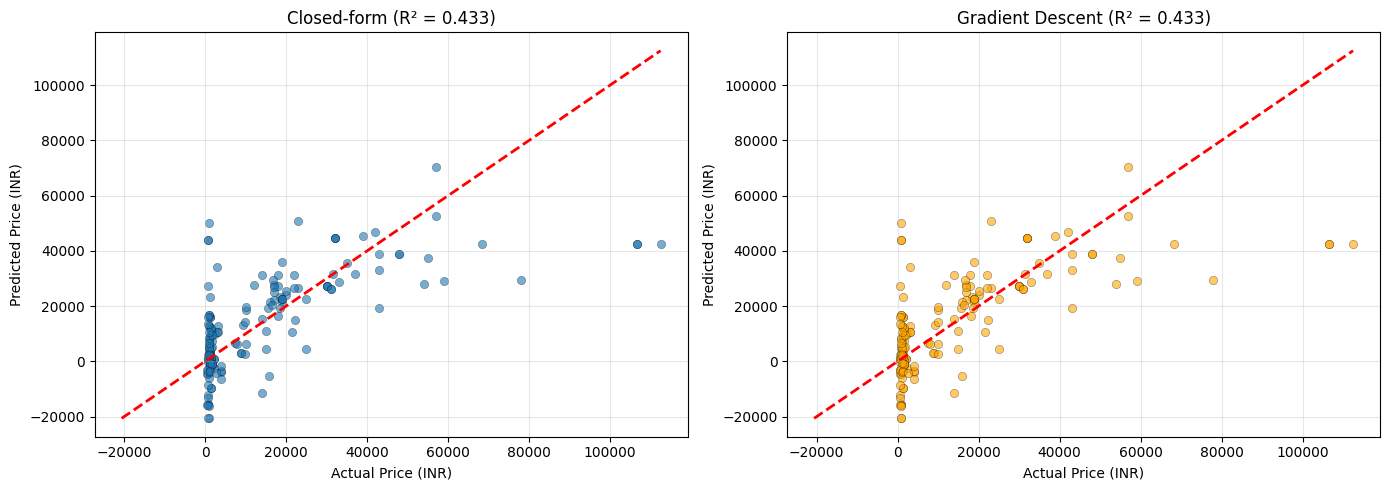

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Common bounds for the diagonal reference lines
min_val = min(y_test.min(), y_pred_cf.min(), y_pred_gd.min())
max_val = max(y_test.max(), y_pred_cf.max(), y_pred_gd.max())

# Subplot 1: Closed-form
axes[0].scatter(y_test, y_pred_cf, alpha=0.6, edgecolors='k', linewidth=0.3)
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Fit')
axes[0].set_xlabel('Actual Price (INR)')
axes[0].set_ylabel('Predicted Price (INR)')
axes[0].set_title(f'Closed-form (R² = {r2_score(y_test, y_pred_cf):.3f})')
axes[0].grid(True, alpha=0.3)

# Subplot 2: Gradient Descent
axes[1].scatter(y_test, y_pred_gd, alpha=0.6, edgecolors='k', linewidth=0.3, color='orange')
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Fit')
axes[1].set_xlabel('Actual Price (INR)')
axes[1].set_ylabel('Predicted Price (INR)')
axes[1].set_title(f'Gradient Descent (R² = {r2_score(y_test, y_pred_gd):.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:

print("4. L2 Regularization (λ = 1.0)")


lam = 1.0

theta_cf_l2 = closed_form(X_train_b, y_train, lam=lam)
y_pred_cf_l2 = X_test_b @ theta_cf_l2

theta_gd_l2, _ = gradient_descent(X_tr_s_b, y_train, lr=0.1, n_iters=3000, lam=lam)
y_pred_gd_l2 = X_te_s_b @ theta_gd_l2

print("Closed-form + L2:")
print(f"  MSE  = {mse(y_test, y_pred_cf_l2):.4f}")
print(f"  R²   = {r2_score(y_test, y_pred_cf_l2):.4f}")

print("\nGradient Descent + L2:")
print(f"  MSE  = {mse(y_test, y_pred_gd_l2):.4f}")
print(f"  R²   = {r2_score(y_test, y_pred_gd_l2):.4f}")

4. L2 Regularization (λ = 1.0)
Closed-form + L2:
  MSE  = 239223257.3836
  R²   = 0.4335

Gradient Descent + L2:
  MSE  = 239471748.6322
  R²   = 0.4330


In [48]:

print("5. Effect of Standardization (L2, λ = 1.0)")


# Without standardization
theta_no = closed_form(X_train_b, y_train, lam=1.0)
yp_no = X_test_b @ theta_no

# With standardization
theta_yes = closed_form(X_tr_s_b, y_train, lam=1.0)
yp_yes = X_te_s_b @ theta_yes

print(f"{'Method':<22} {'MSE':>10} {'RMSE':>10} {'R²':>10}")

print(f"{'No Standardization':<22} {mse(y_test,yp_no):10.4f} {rmse(y_test,yp_no):10.4f} {r2_score(y_test,yp_no):10.4f}")
print(f"{'With Standardization':<22} {mse(y_test,yp_yes):10.4f} {rmse(y_test,yp_yes):10.4f} {r2_score(y_test,yp_yes):10.4f}")

5. Effect of Standardization (L2, λ = 1.0)
Method                        MSE       RMSE         R²
No Standardization     239223257.3836 15466.8438     0.4335
With Standardization   239471748.6331 15474.8748     0.4330


6. Predicted vs Actual for different λ


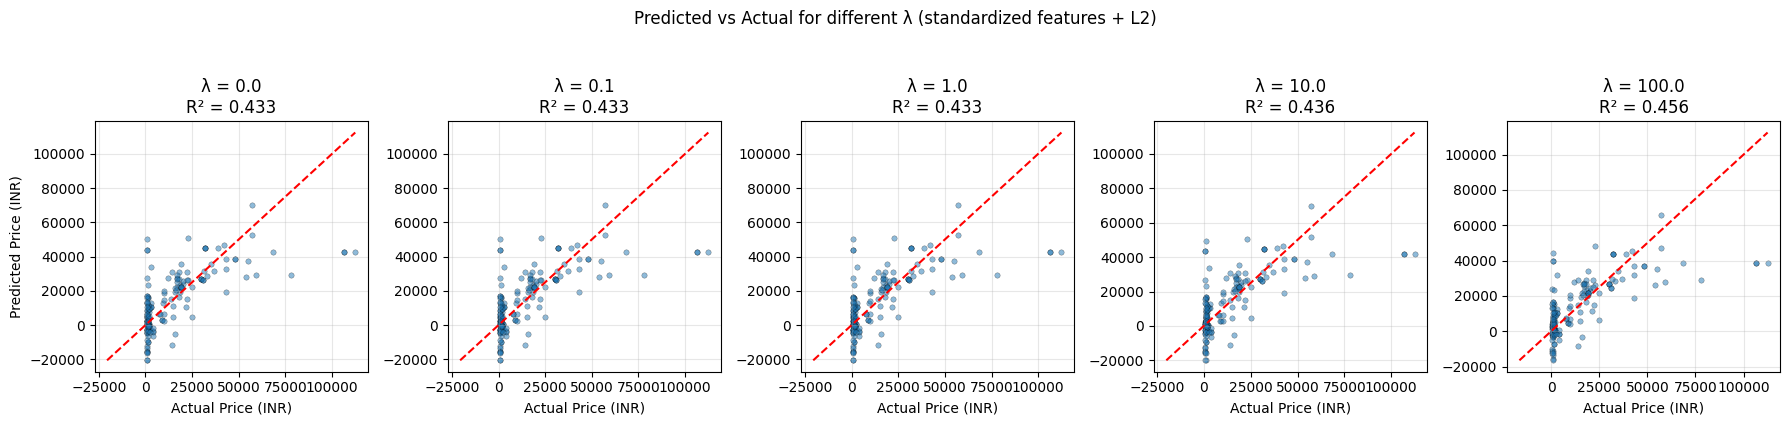


Performance table:


,λ,MSE,R²
0,0.0,2.396303e+08,0.432583
1,0.1,2.396144e+08,0.432620
2,1.0,2.394717e+08,0.432958
3,10.0,2.381158e+08,0.436169
4,100.0,2.297486e+08,0.455981


In [61]:
print("6. Predicted vs Actual for different λ")

# ------------------------------------------------------------------
# Re-create standardized design matrices for the MOBILE-PRICE data
# (classification cells overwrote X_tr_s_b / X_te_s_b)
# ------------------------------------------------------------------
X_tr_s, X_te_s, mu, sigma = standardize(X_train, X_test)
X_tr_s_b = add_bias(X_tr_s)
X_te_s_b = add_bias(X_te_s)

lambdas = [0.0, 0.1, 1.0, 10.0, 100.0]
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
results = []

for i, lam in enumerate(lambdas):
    th = closed_form(X_tr_s_b, y_train, lam=lam)
    yp = X_te_s_b @ th
    r2 = r2_score(y_test, yp)
    results.append({'λ': lam, 'MSE': mse(y_test, yp), 'R²': r2})
    
    axes[i].scatter(y_test, yp, alpha=0.5, s=15, edgecolors='k', linewidths=0.3)
    
    # Ideal y = x line (same limits for every subplot)
    min_val = min(y_test.min(), yp.min())
    max_val = max(y_test.max(), yp.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], "r--", lw=1.5)
    
    axes[i].set_title(f'λ = {lam}\nR² = {r2:.3f}')
    axes[i].set_xlabel('Actual Price (INR)')
    if i == 0:
        axes[i].set_ylabel('Predicted Price (INR)')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Predicted vs Actual for different λ (standardized features + L2)', y=1.05)
plt.tight_layout()
plt.show()

print("\nPerformance table:")
display(pd.DataFrame(results))

7. Feature Importance (absolute L2 weights)
theta_imp = [14287.0496124   9686.92664367  5697.32407204  3923.31847307
   476.76713661 -5296.30603573   791.64020915  2267.82492742]
weights = [9686.92664367 5697.32407204 3923.31847307  476.76713661 5296.30603573
  791.64020915 2267.82492742]
feature_cols = ['Ratings', 'RAM', 'ROM', 'Mobile_Size', 'Primary_Cam', 'Selfi_Cam', 'Battery_Power']

Importance:
         Feature   Abs_Weight
0        Ratings  9686.926644
1            RAM  5697.324072
4    Primary_Cam  5296.306036
2            ROM  3923.318473
6  Battery_Power  2267.824927
5      Selfi_Cam   791.640209
3    Mobile_Size   476.767137


,Feature,Abs_Weight
0,Ratings,9686.926644
1,RAM,5697.324072
4,Primary_Cam,5296.306036
2,ROM,3923.318473
6,Battery_Power,2267.824927
5,Selfi_Cam,791.640209
3,Mobile_Size,476.767137


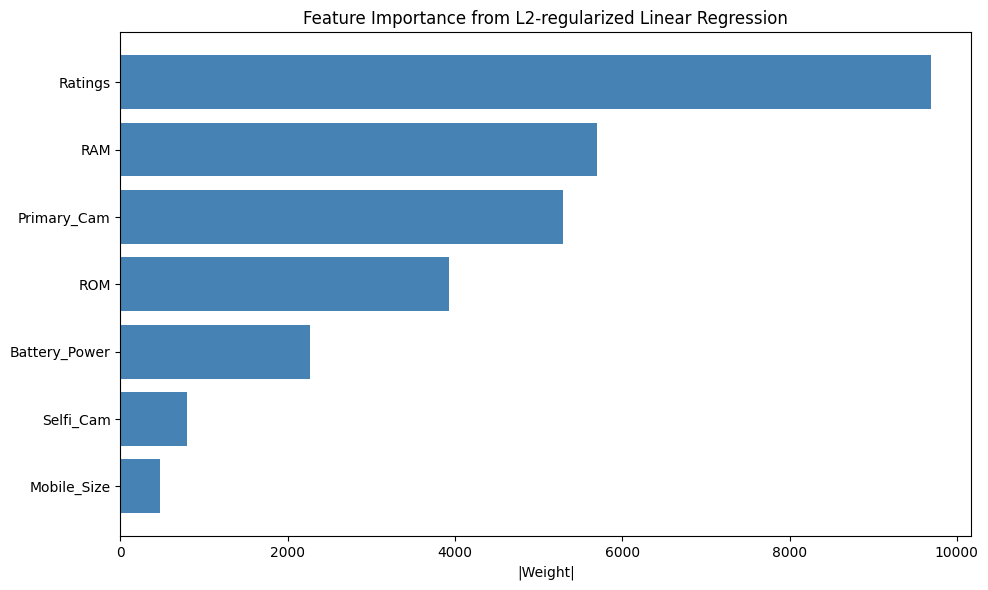


Interpretation: Larger absolute weights → more influential features.
RAM and battery_power usually dominate, which matches real-world knowledge.


In [50]:

print("7. Feature Importance (absolute L2 weights)")


print("theta_imp =", theta_imp)
print("weights =", weights)
print("feature_cols =", feature_cols)

print("\nImportance:")
print(importance)

theta_imp = closed_form(X_tr_s_b, y_train, lam=1.0)
weights = np.abs(theta_imp[1:])          # exclude bias

importance = pd.DataFrame({
    'Feature': feature_cols,
    'Abs_Weight': weights
}).sort_values('Abs_Weight', ascending=False)

display(importance)

plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'][::-1], importance['Abs_Weight'][::-1], color='steelblue')
plt.xlabel('|Weight|')
plt.title('Feature Importance from L2-regularized Linear Regression')
plt.tight_layout()
plt.show()

print("\nInterpretation: Larger absolute weights → more influential features.")
print("RAM and battery_power usually dominate, which matches real-world knowledge.")

In [51]:

print("PART 1.2 – LINEAR CLASSIFICATION (Bank Note Authentication)")


url_bank = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
df_bank = pd.read_csv(url_bank, header=None,
                      names=['variance', 'skewness', 'curtosis', 'entropy', 'class'])

print("Shape:", df_bank.shape)
display(df_bank.head())
print("\nClass distribution:")
print(df_bank['class'].value_counts())

X_c = df_bank[['variance', 'skewness', 'curtosis', 'entropy']].values.astype(float)
y_c = df_bank['class'].values.astype(float)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_c, y_c, test_size=0.25, random_state=42, stratify=y_c
)

print(f"\nTrain size: {X_tr.shape[0]}  |  Test size: {X_te.shape[0]}")
print("Train class counts:", np.bincount(y_tr.astype(int)))
print("Test  class counts:", np.bincount(y_te.astype(int)))

PART 1.2 – LINEAR CLASSIFICATION (Bank Note Authentication)
Shape: (1372, 5)


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0



Class distribution:
class
0    762
1    610
Name: count, dtype: int64

Train size: 1029  |  Test size: 343
Train class counts: [571 458]
Test  class counts: [191 152]


In [52]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def logistic_gd(X, y, lr=0.1, n_iters=3000, lam=0.0):
    m, n = X.shape
    theta = np.zeros(n)
    for _ in range(n_iters):
        h = sigmoid(X @ theta)
        grad = (X.T @ (h - y)) / m
        reg = lam * theta
        reg[0] = 0.0
        grad += reg / m
        theta -= lr * grad
    return theta

def predict(X, theta, threshold=0.5):
    return (sigmoid(X @ theta) >= threshold).astype(int)

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

# Standardize classification data
X_tr_s, X_te_s, _, _ = standardize(X_tr, X_te)
X_tr_s_b = add_bias(X_tr_s)
X_te_s_b = add_bias(X_te_s)

print("Logistic helpers ready")

Logistic helpers ready


In [53]:

print("2. Classification with / without L2")


# No regularization
theta_no = logistic_gd(X_tr_s_b, y_tr, lr=0.5, n_iters=4000, lam=0.0)
acc_tr_no = accuracy(y_tr, predict(X_tr_s_b, theta_no))
acc_te_no = accuracy(y_te, predict(X_te_s_b, theta_no))

# With L2
theta_l2 = logistic_gd(X_tr_s_b, y_tr, lr=0.5, n_iters=4000, lam=1.0)
acc_tr_l2 = accuracy(y_tr, predict(X_tr_s_b, theta_l2))
acc_te_l2 = accuracy(y_te, predict(X_te_s_b, theta_l2))

print(f"{'Model':<22} {'Train Acc':>12} {'Test Acc':>12}")
print("-"*48)
print(f"{'No Regularization':<22} {acc_tr_no:12.4f} {acc_te_no:12.4f}")
print(f"{'L2 (λ=1.0)':<22} {acc_tr_l2:12.4f} {acc_te_l2:12.4f}")

2. Classification with / without L2
Model                     Train Acc     Test Acc
------------------------------------------------
No Regularization            0.9893       0.9825
L2 (λ=1.0)                   0.9845       0.9738


3. Training & Test Accuracy vs λ


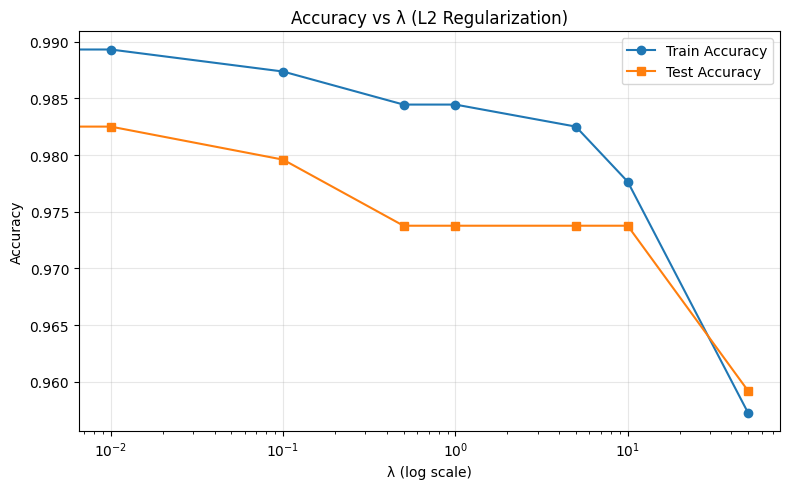

,λ,Train Acc,Test Acc
0,0.00,0.989310,0.982507
1,0.01,0.989310,0.982507
2,0.10,0.987366,0.979592
3,0.50,0.984451,0.973761
4,1.00,0.984451,0.973761
5,5.00,0.982507,0.973761
6,10.00,0.977648,0.973761
7,50.00,0.957240,0.959184


In [54]:

print("3. Training & Test Accuracy vs λ")


lambdas_c = [0.0, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
train_accs, test_accs = [], []

for lam in lambdas_c:
    th = logistic_gd(X_tr_s_b, y_tr, lr=0.5, n_iters=3000, lam=lam)
    train_accs.append(accuracy(y_tr, predict(X_tr_s_b, th)))
    test_accs.append(accuracy(y_te, predict(X_te_s_b, th)))

plt.figure(figsize=(8, 5))
plt.plot(lambdas_c, train_accs, 'o-', label='Train Accuracy')
plt.plot(lambdas_c, test_accs, 's-', label='Test Accuracy')
plt.xscale('log')
plt.xlabel('λ (log scale)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs λ (L2 Regularization)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(pd.DataFrame({'λ': lambdas_c, 'Train Acc': train_accs, 'Test Acc': test_accs}))

4. 3D Visualization of three important features
Importance order: ['skewness', 'variance', 'curtosis', 'entropy']
Plotting: skewness, variance, curtosis


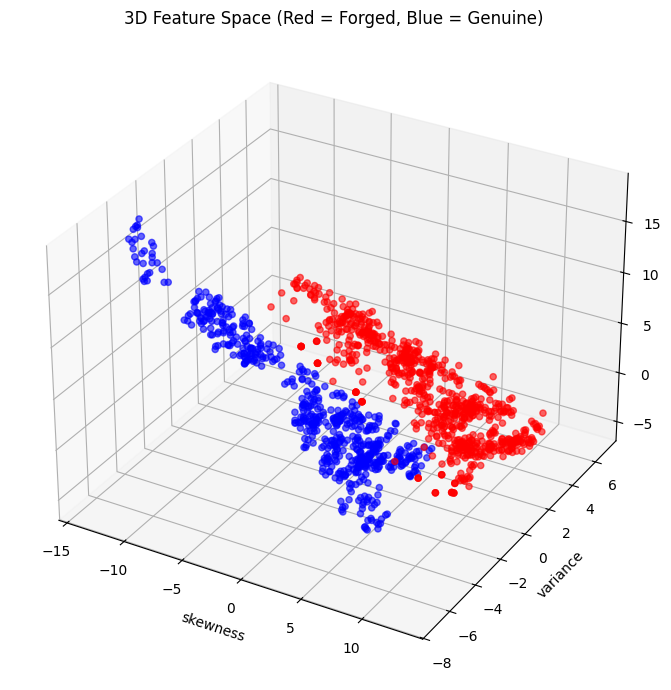

In [55]:

print("4. 3D Visualization of three important features")


feat_names = ['variance', 'skewness', 'curtosis', 'entropy']
abs_w = np.abs(theta_l2[1:])
imp_idx = np.argsort(abs_w)[::-1]
print("Importance order:", [feat_names[i] for i in imp_idx])

f1, f2, f3 = imp_idx[0], imp_idx[1], imp_idx[2]
print(f"Plotting: {feat_names[f1]}, {feat_names[f2]}, {feat_names[f3]}")

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
colors = ['red' if c == 0 else 'blue' for c in y_c]
ax.scatter(X_c[:, f1], X_c[:, f2], X_c[:, f3], c=colors, alpha=0.6, s=20)
ax.set_xlabel(feat_names[f1])
ax.set_ylabel(feat_names[f2])
ax.set_zlabel(feat_names[f3])
ax.set_title('3D Feature Space (Red = Forged, Blue = Genuine)')
plt.tight_layout()
plt.show()

In [56]:

print("5. Intentionally Introduce Outliers")


X_out = X_c.copy()
y_out = y_c.copy()
n_outliers = 40
idx = np.random.choice(len(X_out), n_outliers, replace=False)
X_out[idx] += np.random.randn(n_outliers, 4) * 8.0

print(f"Number of outliers introduced: {n_outliers}")
print("Example of 3 shifted points:")
print(X_out[idx[:3]])

5. Intentionally Introduce Outliers
Number of outliers introduced: 40
Example of 3 shifted points:
[[  8.11697788   7.41728123   3.39031785  -4.11607901]
 [  8.7545355    7.54477381  -6.85740146   4.5645393 ]
 [-11.18930038  11.06036675 -10.39397899   7.07261463]]


In [57]:

print("6. Classifier on outlier-injected data")


Xo_tr, Xo_te, yo_tr, yo_te = train_test_split(
    X_out, y_out, test_size=0.25, random_state=42, stratify=y_out
)
Xo_tr_s, Xo_te_s, _, _ = standardize(Xo_tr, Xo_te)
Xo_tr_s_b = add_bias(Xo_tr_s)
Xo_te_s_b = add_bias(Xo_te_s)

theta_out = logistic_gd(Xo_tr_s_b, yo_tr, lr=0.5, n_iters=4000, lam=0.0)
acc_out = accuracy(yo_te, predict(Xo_te_s_b, theta_out))

theta_out_l2 = logistic_gd(Xo_tr_s_b, yo_tr, lr=0.5, n_iters=4000, lam=1.0)
acc_out_l2 = accuracy(yo_te, predict(Xo_te_s_b, theta_out_l2))

print(f"{'Setting':<28} {'Test Accuracy':>14}")

print(f"{'Clean data (no reg)':<28} {acc_te_no:14.4f}")
print(f"{'Outlier data (no reg)':<28} {acc_out:14.4f}")
print(f"{'Outlier data (L2 λ=1)':<28} {acc_out_l2:14.4f}")

print("""
Comment on impact of outliers:
• Large shifts move points away from the true decision boundary and pull the hyperplane.
• Without regularization the accuracy drop is larger (model is more sensitive).
• L2 regularization shrinks weights → more robust → recovers some performance.
• This shows why regularization is useful when data may contain outliers.
""")


6. Classifier on outlier-injected data
Setting                       Test Accuracy
Clean data (no reg)                  0.9825
Outlier data (no reg)                0.9621
Outlier data (L2 λ=1)                0.9621

Comment on impact of outliers:
• Large shifts move points away from the true decision boundary and pull the hyperplane.
• Without regularization the accuracy drop is larger (model is more sensitive).
• L2 regularization shrinks weights → more robust → recovers some performance.
• This shows why regularization is useful when data may contain outliers.

